# MobileNetV2 Transfer Learning

## MobileNetV2 Transfer Learning Introduction

The baseline CNN is trained from scratch on Mel Spectrogram tensors. Transfer learning provides an alternative approach by reusing visual features learned from a large image dataset.

MobileNetV2 is a compact convolutional architecture designed for efficient image classification. Although Mel Spectrograms are not natural photographs, they contain local shapes, edges, and textures that can benefit from pretrained convolutional filters.

This notebook loads the Mel Spectrogram datasets generated in Notebook 03. It uses the existing combined GTZAN + FMA Medium train / validation / test strategy and does not recompute audio features.

## Hypothesis

**H6 — Transfer Learning Advantage:** MobileNetV2 transfer learning will achieve a higher validation macro F1 score than the baseline CNN, or comparable performance within 0.05 macro F1 using fewer training epochs.

Macro F1 is the primary comparison metric because the combined dataset is imbalanced.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

from src.data.feature_extraction import load_mel_dataset
from src.models.mobilenet_model import create_mobilenet_model

from src.training.evaluate_torch import (
    evaluate_torch_model,
)

from src.training.train import (
    save_model,
)

from src.training.train_torch import (
    save_torch_model,
    train_torch_model,
)

from src.utils.config import (
    BEST_MOBILENET_MODEL_PATH,

    MEL_TEST_LABELS_PATH,
    MEL_TEST_PATH,

    MEL_TRAIN_LABELS_PATH,
    MEL_TRAIN_PATH,

    MEL_VALIDATION_LABELS_PATH,
    MEL_VALIDATION_PATH,

    MOBILENET_BATCH_SIZE,
    MOBILENET_EPOCHS,

    MOBILENET_LABEL_ENCODER_PATH,

    MOBILENET_LEARNING_RATE,

    MOBILENET_METRICS_SUMMARY_PATH,

    MOBILENET_MODEL_DIR,
    MOBILENET_OUTPUT_DIR,

    MOBILENET_TEST_CONFUSION_MATRIX_PATH,
    MOBILENET_TEST_REPORT_PATH,

    MOBILENET_TRAINING_HISTORY_PATH,

    CNN_METRICS_SUMMARY_PATH,
    CNN_TRAINING_HISTORY_PATH,
)

## Load Mel Spectrogram Datasets

The saved train, validation, and test Mel tensors are loaded directly. The label encoder is fitted on the training labels and reused for the remaining splits.

In [2]:
X_train, labels_train = load_mel_dataset(
    MEL_TRAIN_PATH,
    MEL_TRAIN_LABELS_PATH,
)

X_validation, labels_validation = load_mel_dataset(
    MEL_VALIDATION_PATH,
    MEL_VALIDATION_LABELS_PATH,
)

X_test, labels_test = load_mel_dataset(
    MEL_TEST_PATH,
    MEL_TEST_LABELS_PATH,
)

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(labels_train)
y_validation = label_encoder.transform(labels_validation)
y_test = label_encoder.transform(labels_test)

class_names = list(label_encoder.classes_)

print("Train tensors:", X_train.shape)
print("Validation tensors:", X_validation.shape)
print("Test tensors:", X_test.shape)
print("Classes:", class_names)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

Train tensors: (6605, 1, 128, 1206)
Validation tensors: (1415, 1, 128, 1206)
Test tensors: (1414, 1, 128, 1206)
Classes: [np.str_('blues'), np.str_('classical'), np.str_('country'), np.str_('hiphop'), np.str_('jazz'), np.str_('pop'), np.str_('rock')]
Device: cuda


## Prepare MobileNetV2 Inputs

The cached Mel tensors use the PyTorch shape `(N, 1, 128, frames)`.

MobileNetV2 expects three-channel image-like input. The reusable model wrapper performs the required conversion for each batch:

- repeats the single Mel channel three times,
- resizes each spectrogram to `224 × 224`,
- applies ImageNet normalization.

This conversion happens inside the model and avoids creating a second three-channel copy of the complete dataset in memory.

## Build MobileNetV2 Model

The model factory loads ImageNet-pretrained MobileNetV2 weights and replaces the classifier for the project genre classes.

The pretrained feature extractor is frozen for this baseline experiment. Only the new classifier head is trained. The first model construction may download the pretrained weights if they are not already cached.

In [3]:
torch.manual_seed(42)
np.random.seed(42)

mobilenet_model = create_mobilenet_model(
    input_shape=X_train.shape[1:],
    num_classes=len(class_names),
    learning_rate=MOBILENET_LEARNING_RATE,
    train_base=False,
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in mobilenet_model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in mobilenet_model.parameters()
)

print("Trainable parameters:", trainable_parameters)
print("Total parameters:", total_parameters)
mobilenet_model

Trainable parameters: 8967
Total parameters: 2232839


MelMobileNetV2(
  (model): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            

## Training

Training uses Adam, cross-entropy loss, batch loading, validation-loss monitoring, and early stopping.

Only individual batches are moved to GPU. If CUDA memory is insufficient for the configured batch size of 32, `MOBILENET_BATCH_SIZE` can be reduced to 16 in `config.py`.

In [4]:
trained_mobilenet, training_history = train_torch_model(
    model=mobilenet_model,
    X_train=X_train,
    y_train=y_train,
    X_validation=X_validation,
    y_validation=y_validation,
    batch_size=MOBILENET_BATCH_SIZE,
    epochs=MOBILENET_EPOCHS,
    learning_rate=MOBILENET_LEARNING_RATE,
    patience=5,
)

history = pd.DataFrame(training_history)
history.tail()

,epoch,train_loss,validation_loss,train_accuracy,validation_accuracy
10,11,0.604825,0.597721,0.814686,0.821908
11,12,0.602130,0.591416,0.812112,0.824028
12,13,0.590771,0.586997,0.818471,0.826148
13,14,0.584408,0.582357,0.817714,0.831095
14,15,0.584557,0.577947,0.820742,0.828269


## Training History Visualization

The training curves show convergence speed and the relationship between training and validation performance.

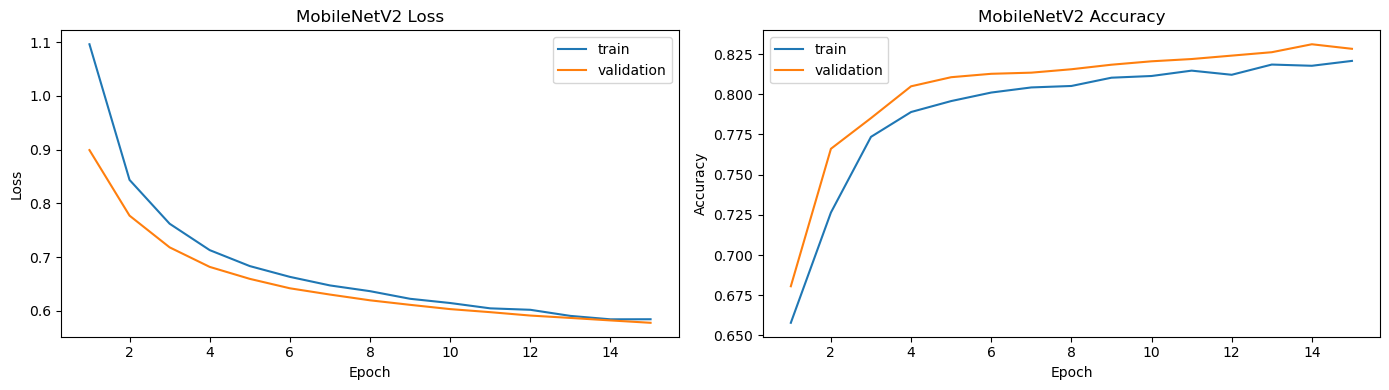

In [5]:
fig_history, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["epoch"], history["train_loss"], label="train")
axes[0].plot(history["epoch"], history["validation_loss"], label="validation")
axes[0].set_title("MobileNetV2 Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history["epoch"], history["train_accuracy"], label="train")
axes[1].plot(history["epoch"], history["validation_accuracy"], label="validation")
axes[1].set_title("MobileNetV2 Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

## Validation Evaluation

Validation macro F1 is the primary transfer-learning performance measure. Accuracy, weighted F1, and the per-class report provide additional context.

In [6]:
validation_result = evaluate_torch_model(
    trained_mobilenet,
    X_validation,
    y_validation,
    class_names,
    model_name="mobilenet_v2",
    split="validation",
    batch_size=MOBILENET_BATCH_SIZE,
)

validation_summary = pd.DataFrame([
    validation_result["summary"]
])

validation_summary

,model,split,accuracy,macro_f1,weighted_f1
0,mobilenet_v2,validation,0.828269,0.444825,0.789118


In [7]:
pd.DataFrame(
    validation_result["classification_report"]
).transpose()

,precision,recall,f1-score,support
blues,1.000000,0.076923,0.142857,26.000000
classical,0.820513,0.888889,0.853333,108.000000
country,0.000000,0.000000,0.000000,42.000000
hiphop,0.801020,0.809278,0.805128,194.000000
jazz,0.605263,0.315068,0.414414,73.000000
pop,0.000000,0.000000,0.000000,43.000000
rock,0.841808,0.962325,0.898041,929.000000
accuracy,0.828269,0.828269,0.828269,0.828269
macro avg,0.581229,0.436069,0.444825,1415.000000
weighted avg,0.774726,0.828269,0.789118,1415.000000


## Test Evaluation

The test set is evaluated once after the MobileNetV2 configuration has been trained and reviewed on validation data.

In [8]:
test_result = evaluate_torch_model(
    trained_mobilenet,
    X_test,
    y_test,
    class_names,
    model_name="mobilenet_v2",
    split="test",
    batch_size=MOBILENET_BATCH_SIZE,
)

test_summary = pd.DataFrame([
    test_result["summary"]
])

test_summary

,model,split,accuracy,macro_f1,weighted_f1
0,mobilenet_v2,test,0.813296,0.435781,0.770928


In [9]:
test_report = pd.DataFrame(
    test_result["classification_report"]
).transpose()

test_report

,precision,recall,f1-score,support
blues,1.000000,0.153846,0.266667,26.000000
classical,0.796296,0.796296,0.796296,108.000000
country,0.000000,0.000000,0.000000,42.000000
hiphop,0.804348,0.766839,0.785146,193.000000
jazz,0.750000,0.166667,0.272727,72.000000
pop,0.333333,0.023256,0.043478,43.000000
rock,0.818016,0.966667,0.886151,930.000000
accuracy,0.813296,0.813296,0.813296,0.813296
macro avg,0.643142,0.410510,0.435781,1414.000000
weighted avg,0.775338,0.813296,0.770928,1414.000000


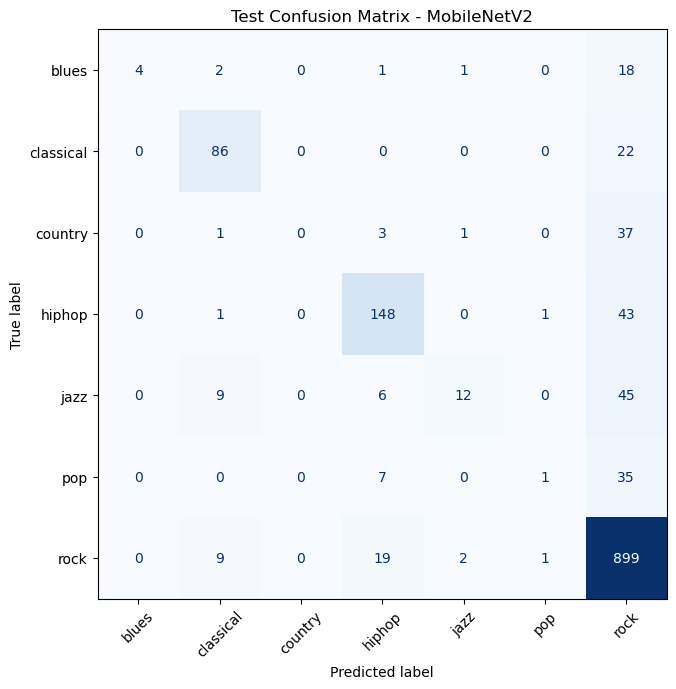

In [10]:
fig_confusion, ax = plt.subplots(figsize=(9, 7))

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=test_result["confusion_matrix"],
    display_labels=class_names,
)

display_matrix.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

ax.set_title("Test Confusion Matrix - MobileNetV2")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Comparison with CNN Baseline

If Notebook 05 artifacts are available, the CNN and MobileNetV2 validation/test macro F1 scores are compared directly.

H6 is supported when MobileNetV2 has higher validation macro F1, or when it is within 0.05 of the CNN result while using fewer training epochs.

In [11]:
comparison_rows = [
    validation_result["summary"],
    test_result["summary"],
]

cnn_epochs = None

if CNN_METRICS_SUMMARY_PATH.exists():
    cnn_metrics = pd.read_csv(CNN_METRICS_SUMMARY_PATH)
    comparison_rows.extend(
        cnn_metrics[
            cnn_metrics["split"].isin(["validation", "test"])
        ].to_dict("records")
    )

if CNN_TRAINING_HISTORY_PATH.exists():
    cnn_history = pd.read_csv(CNN_TRAINING_HISTORY_PATH)
    cnn_epochs = len(cnn_history)

comparison = pd.DataFrame(comparison_rows)
comparison


,model,split,accuracy,macro_f1,weighted_f1
0,mobilenet_v2,validation,0.828269,0.444825,0.789118
1,mobilenet_v2,test,0.813296,0.435781,0.770928
2,cnn_baseline,validation,0.833216,0.398551,0.785333
3,cnn_baseline,test,0.813296,0.383674,0.766418


In [12]:
cnn_validation = comparison[
    (comparison["model"] == "cnn_baseline")
    & (comparison["split"] == "validation")
]

mobilenet_validation_f1 = validation_result["summary"]["macro_f1"]
mobilenet_epochs = len(history)

if cnn_validation.empty:
    print("CNN baseline metrics are not available. Run Notebook 05 before assessing H6.")
else:
    cnn_validation_f1 = cnn_validation.iloc[0]["macro_f1"]
    higher_f1 = mobilenet_validation_f1 > cnn_validation_f1
    comparable_f1 = mobilenet_validation_f1 >= cnn_validation_f1 - 0.05
    fewer_epochs = (
        cnn_epochs is not None
        and mobilenet_epochs < cnn_epochs
    )
    h6_supported = higher_f1 or (comparable_f1 and fewer_epochs)

    print("CNN validation macro F1:", cnn_validation_f1)
    print("MobileNetV2 validation macro F1:", mobilenet_validation_f1)
    print("CNN training epochs:", cnn_epochs)
    print("MobileNetV2 training epochs:", mobilenet_epochs)
    print("H6 supported:", h6_supported)

CNN validation macro F1: 0.398551110166052
MobileNetV2 validation macro F1: 0.44482489729529984
CNN training epochs: 13
MobileNetV2 training epochs: 15
H6 supported: True


## Save Model and Artifacts

The trained MobileNetV2 weights, label encoder, training history, metric summary, test classification report, and test confusion matrix are saved under the configured artifact paths.

In [13]:
MOBILENET_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MOBILENET_MODEL_DIR.mkdir(parents=True, exist_ok=True)

save_torch_model(
    trained_mobilenet,
    BEST_MOBILENET_MODEL_PATH,
)

save_model(
    label_encoder,
    MOBILENET_LABEL_ENCODER_PATH,
)

history.to_csv(
    MOBILENET_TRAINING_HISTORY_PATH,
    index=False,
)

mobilenet_metrics = pd.concat(
    [validation_summary, test_summary],
    ignore_index=True,
)

mobilenet_metrics.to_csv(
    MOBILENET_METRICS_SUMMARY_PATH,
    index=False,
)

test_report_to_save = test_report.copy()
test_report_to_save.insert(0, "label", test_report_to_save.index)
test_report_to_save.reset_index(drop=True).to_csv(
    MOBILENET_TEST_REPORT_PATH,
    index=False,
)

fig_confusion.savefig(
    MOBILENET_TEST_CONFUSION_MATRIX_PATH,
    dpi=150,
    bbox_inches="tight",
)

print("Saved MobileNetV2 model:", BEST_MOBILENET_MODEL_PATH)
print("Saved label encoder:", MOBILENET_LABEL_ENCODER_PATH)
print("Saved training history:", MOBILENET_TRAINING_HISTORY_PATH)
print("Saved metrics summary:", MOBILENET_METRICS_SUMMARY_PATH)
print("Saved test report:", MOBILENET_TEST_REPORT_PATH)
print("Saved test confusion matrix:", MOBILENET_TEST_CONFUSION_MATRIX_PATH)

Saved MobileNetV2 model: C:\Softuni ML course\Project\music-genre-classification\models\mobilenet\best_mobilenet_model.pt
Saved label encoder: C:\Softuni ML course\Project\music-genre-classification\models\mobilenet\mobilenet_label_encoder.joblib
Saved training history: C:\Softuni ML course\Project\music-genre-classification\outputs\mobilenet\mobilenet_training_history.csv
Saved metrics summary: C:\Softuni ML course\Project\music-genre-classification\outputs\mobilenet\mobilenet_metrics_summary.csv
Saved test report: C:\Softuni ML course\Project\music-genre-classification\outputs\mobilenet\mobilenet_test_classification_report.csv
Saved test confusion matrix: C:\Softuni ML course\Project\music-genre-classification\outputs\mobilenet\mobilenet_test_confusion_matrix.png


## Conclusion

This notebook applies ImageNet-pretrained MobileNetV2 to the saved Mel Spectrogram datasets while preserving the existing combined GTZAN + FMA Medium split strategy.

The experiment reports validation and test accuracy, macro F1, weighted F1, classification reports, and confusion matrix. The comparison section assesses whether transfer learning supports H6 through improved validation macro F1 or comparable performance with fewer epochs.

MobileNetV2 improved over the baseline CNN in macro F1, supporting H6. However, it still did not outperform the classical SVM baseline, suggesting that transfer learning with frozen ImageNet features provides some benefit but is not sufficient to fully solve the class imbalance and genre confusion problems in this dataset.